## Setup

#### in R: save CpG annotations - RUN ONCE
`BiocManager::install("IlluminaHumanMethylationEPICanno.ilm10b4.hg19")` <br>
`library(IlluminaHumanMethylationEPICanno.ilm10b4.hg19)` <br>
`anno <-getAnnotation(IlluminaHumanMethylationEPICanno.ilm10b4.hg19) %>% as_tibble` <br>
`fwrite(anno, 'anno_epic.csv', sep = ",", quote=TRUE)` <br>
`system('dx upload --brief anno_epic.csv --dest vasilis/data/ebb/')` <br>

In [5]:
import os
import glob
import pandas as pd
from pandas.core.common import flatten
import re
import numpy as np
import seaborn as sns
from tqdm import tqdm
import time
import sys
#import statsmodels.api as sm
from scipy import stats
#from scipy.stats import zscore
#from scipy.stats import pearsonr

## 1. Process MWAS results
- batch results in: `vasilis/data/ebb/results/[phecode]__batch*.csv`
- merge all batches for each phenotype
- clean results in:  `vasilis/data/ebb/results_clean/[phecode]_mwas_assoc.csv`
- add metadata
- filter heritabilities, estimated in EBB

In [6]:
## load annotations
!dx download -f vasilis/data/ebb/anno_epic.csv
anno = pd.read_csv('anno_epic.csv')

[===========================================================>] Completed 539,548,215 of 539,548,215 bytes (100%) /opt/notebooks/anno_epic.csvv


/tmp/ipykernel_70/274319580.py:3: DtypeWarning: Columns (7,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  anno = pd.read_csv('anno_epic.csv')


In [7]:
## get cpg genomic positions (hg37)
pos = anno[['Name', 'chr', 'pos']].rename(columns = {'Name': 'cpg'}).set_index('cpg')
pos = pos.loc[ ~ pos['chr'].isin(['chrX', 'chrY']) ]
pos['chr'] = pd.to_numeric(pos['chr'].str.replace('chr', '', regex=False), errors='coerce')
pos.head()

,chr,pos
cpg,,
cg18478105,20,61847650
cg14361672,9,131463936
cg01763666,17,80159506
cg12950382,14,105176736
cg02115394,13,115000168


In [8]:
## load heritabilities
!dx download -f vasilis/data/ebb/EBB.BRAIN.METHYL.HERIT.profile
ebb_profile = pd.read_csv('EBB.BRAIN.METHYL.HERIT.profile', sep="\t")
hsq = ebb_profile[['id','hsq', 'hsq.se', 'hsq.pv']].rename(columns = {'id': 'cpg', 'hsq': 'ebb.hsq', 'hsq.se': 'ebb.hsq.se', 'hsq.pv': 'ebb.hsq.pv'}).set_index('cpg')
hsq.head()

[===========================================================>] Completed 11,656,393 of 11,656,393 bytes (100%) /opt/notebooks/EBB.BRAIN.METHYL.HERIT.profilee


,ebb.hsq,ebb.hsq.se,ebb.hsq.pv
cpg,,,
cg23009899,0.405,0.136,2.700000e-04
cg13716778,0.128,0.106,1.900000e-02
cg01713086,0.274,0.132,1.600000e-03
cg07802949,0.718,0.097,1.000000e-14
cg27435867,0.836,0.067,2.400000e-13


In [9]:
## load phecode ids & description
!dx download -f vasilis/data/ebb/phenotypes/phecode_map.csv
phecodes = pd.read_csv('phecode_map.csv')[['phecode', 'description', 'group', 'color']].drop_duplicates()
print(phecodes.shape[0])
phecodes.head()

[===========================================================>] Completed 38,371 of 38,371 bytes (100%) /opt/notebooks/phecode_map.csvv
445


,phecode,description,group,color
0,GI_526,Intestinal infection,Gastrointestinal,#FFD700
1,ID_001,Salmonella,Infections,#FF0000
2,ID_089.1,Bacterial infections,Infections,#FF0000
3,GI_526.1,Bacterial enteritis,Gastrointestinal,#FFD700
7,ID_027,Shigella,Infections,#FF0000


#### for all phenotypes

In [ ]:
## make results tables

!mkdir -p results

mwaspath = 'vasilis/data/ebb/results/'
n_pheno  = phecodes.shape[0] 

for j in tqdm(range(n_pheno)):
    
    # get pheno j name & path
    pheno_name_j  = phecodes.iloc[j]['phecode']
    description_j = phecodes.iloc[j]['description']
    mwas_phe_j    = pheno_name_j + '__batch*.csv' 
    mwas_phe_j_fp = mwaspath + pheno_name_j + '__batch*.csv' 
    
    # download mwas results batches [1-50]
    !dx download -f --no-progress {mwas_phe_j_fp}
    !mv {mwas_phe_j} results/
    
    # load in python and concatenate
    glob_j  = 'results/' + mwas_phe_j 
    files_j = glob.glob(glob_j)
    mwas_j  = pd.concat((pd.read_csv(f) for f in files_j), ignore_index=True)
    
    # add metadata
    mwas_j.phecode = pheno_name_j
    mwas_j.name    = description_j
    print(mwas_j.phecode, mwas_j.name)
    
    # add cpg genomic positions
    mwas_j = mwas_j.set_index('cpg').join(pos, how='inner').sort_values(['chr', 'pos'])
    
    # add heritabilities
    mwas_j = mwas_j.join(hsq, how='left').reset_index()
    
    # save df
    outfile_j = pheno_name_j + '_mwas_assoc.csv'
    mwas_j.to_csv(outfile_j, index=False)
    
    # upload
    !dx upload --brief --no-progress {outfile_j} --dest vasilis/data/ebb/results_clean/

    # cleanup
    !rm results/*

#### for sensitivity: *APOE-e4* adjusted delirium

In [25]:
## non-adjusted delirium results
!dx download -f --no-progress vasilis/data/ebb/results_clean/MB_308.1_mwas_assoc.csv
delir = pd.read_csv('MB_308.1_mwas_assoc.csv').set_index('cpg')

In [51]:
thres =  0.05 / ( delir.shape[0] * 445 )
delir_signif = delir.loc[ delir['pvalue'] < thres ].index.values
delir.loc[delir_signif]

,beta,se,lci,uci,zscore,pvalue,r,n_cas,n_cnt,chr,pos,ebb.hsq,ebb.hsq.se,ebb.hsq.pv
cpg,,,,,,,,,,,,,,
cg25727206,-0.004072,0.000222,-0.004507,-0.003638,-18.383615,1.906883e-75,-0.028783,8379,399227,19,45055395,0.247,0.153,3.800000e-02
cg20051876,0.002069,0.000222,0.001634,0.002503,9.334661,1.017982e-20,0.014620,8379,399227,19,45407860,0.655,0.112,6.000000e-07
cg14123992,0.001681,0.000222,0.001247,0.002116,7.587607,3.265522e-14,0.011884,8379,399227,19,45407868,0.629,0.115,1.800000e-06
cg04406254,0.002029,0.000222,0.001594,0.002463,9.154210,5.499889e-20,0.014337,8379,399227,19,45407945,0.396,0.135,4.800000e-04
cg17928676,0.001881,0.000222,0.001447,0.002316,8.489956,2.073939e-17,0.013297,8379,399227,19,45414742,0.406,0.137,1.100000e-04
cg24640084,0.002390,0.000222,0.001955,0.002824,10.783898,4.136023e-27,0.016889,8379,399227,19,45550554,0.321,0.147,4.300000e-03


In [35]:
sens    = 'MB_308.1' + '__batch*_' + 'e4adj' + '.csv' 
sens_fp = 'vasilis/data/ebb/results/' + sens

# download mwas results batches [1-50]
!mkdir -p results
!dx download -f --no-progress {sens_fp}
!mv {sens} results/

# load in python and concatenate
glob_j    = 'results/' + sens 
files_j   = glob.glob(glob_j)
del_e4adj = pd.concat((pd.read_csv(f) for f in files_j), ignore_index=True)


In [36]:
# add cpg genomic positions
del_e4adj = del_e4adj.set_index('cpg').join(pos, how='inner').sort_values(['chr', 'pos'])

# add heritabilities
del_e4adj = del_e4adj.join(hsq, how='left').reset_index()

# save df
outfile_j = 'MB_308.1_e4adj_mwas_assoc.csv'
del_e4adj.to_csv(outfile_j, index=False)

# upload
!dx upload --brief --no-progress {outfile_j} --dest vasilis/data/ebb/results_clean/

# cleanup
# !rm results/*

file-J6FQQv0JZB7PZ2Gpj58xFQ6f


In [52]:
del_e4adj.loc[ del_e4adj['pvalue'] < 0.05 / del_e4adj.shape[0] ]

,cpg,beta,se,lci,uci,zscore,pvalue,r,n_cas,n_cnt,chr,pos,ebb.hsq,ebb.hsq.se,ebb.hsq.pv
70684,cg14187687,0.001151,0.000221,0.000717,0.001585,5.202434,1.967900e-07,0.008148,8379,399227,14,55249770,0.157,0.114,0.0081


In [53]:
del_e4adj.loc[ del_e4adj['cpg'].isin(delir_signif) ]

,cpg,beta,se,lci,uci,zscore,pvalue,r,n_cas,n_cnt,chr,pos,ebb.hsq,ebb.hsq.se,ebb.hsq.pv
91234,cg25727206,-0.000367,0.000221,-0.000801,0.000066,-1.659930,0.096929,-0.002600,8379,399227,19,45055395,0.247,0.153,3.800000e-02
91256,cg20051876,-0.000182,0.000221,-0.000616,0.000252,-0.822782,0.410633,-0.001289,8379,399227,19,45407860,0.655,0.112,6.000000e-07
91257,cg14123992,-0.000369,0.000221,-0.000803,0.000065,-1.667451,0.095426,-0.002612,8379,399227,19,45407868,0.629,0.115,1.800000e-06
91258,cg04406254,-0.000226,0.000221,-0.000659,0.000208,-1.019363,0.308031,-0.001597,8379,399227,19,45407945,0.396,0.135,4.800000e-04
91259,cg17928676,0.000095,0.000221,-0.000339,0.000529,0.429401,0.667632,0.000673,8379,399227,19,45414742,0.406,0.137,1.100000e-04
91275,cg24640084,0.000014,0.000221,-0.000420,0.000447,0.062105,0.950480,0.000097,8379,399227,19,45550554,0.321,0.147,4.300000e-03


#### for sensitivity: *APOE-e4* adjusted dementia

In [2]:
sens    = 'NS_328.1' + '__batch*_' + 'e4adj' + '.csv' 
sens_fp = 'vasilis/data/ebb/results/' + sens

# download mwas results batches [1-50]
!mkdir -p results
!dx download -f --no-progress {sens_fp}
!mv {sens} results/

# load in python and concatenate
glob_j    = 'results/' + sens 
files_j   = glob.glob(glob_j)
dem_e4adj = pd.concat((pd.read_csv(f) for f in files_j), ignore_index=True)


In [7]:
# add cpg genomic positions
dem_e4adj = dem_e4adj.set_index('cpg').join(pos, how='inner').sort_values(['chr', 'pos'])

# add heritabilities
dem_e4adj = dem_e4adj.join(hsq, how='left').reset_index()

# save df
outfile_j = 'NS_328.1' + '_e4adj_mwas_assoc.csv'
dem_e4adj.to_csv(outfile_j, index=False)

# upload
!dx upload --brief --no-progress {outfile_j} --dest vasilis/data/ebb/results_clean/

# cleanup
# !rm results/*

file-J6G4v78JZB7GbfY9VpYqzGYZ


In [9]:
dem_e4adj.loc[ dem_e4adj['pvalue'] < 0.05 / dem_e4adj.shape[0] ]

,cpg,beta,se,lci,uci,zscore,pvalue,r,n_cas,n_cnt,chr,pos,ebb.hsq,ebb.hsq.se,ebb.hsq.pv
75521,cg10943955,0.000949,0.000183,0.00059,0.001308,5.177747,2.246873e-07,0.00811,5731,401875,16,2081446,0.327,0.149,0.002


## 2. get lead CpG hits

see: https://cloufield.github.io/gwaslab/ExtractLead/#get_lead <br>

*"We defined genome-wide significant loci by iteratively spanning the ±500 kb region around the most significant variant and merging overlapping regions until no genome-wide significant variants were detected within ±1 Mb."*



In [3]:
# !pip install gwaslab==4.0.0

In [4]:
import gwaslab as gl
gl.show_version()

2026/04/08 14:21:55 GWASLab v4.0.0 https://cloufield.github.io/gwaslab/
2026/04/08 14:21:55 (C) 2022-2026, Yunye He, Kamatani Lab, GPL-3.0 license, gwaslab@gmail.com
2026/04/08 14:21:55 Python version: 3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 18:56:27) [GCC 11.2.0]


In [82]:
pheno_name_j  = phecodes.iloc[j]['phecode']
description_j = phecodes.iloc[j]['description']
group_j = phecodes.iloc[j]['group']
color_j = phecodes.iloc[j]['color']


lead_out['phecode'] = pheno_name_j
lead_out['pheno'] = description_j
lead_out['group'] = group_j
lead_out['color'] = color_j


In [83]:
## make results tables

!mkdir -p results

mwaspath = 'vasilis/data/ebb/results_clean/'
n_pheno  = phecodes.shape[0] 

# significance threshold
thres = 0.05 / (99105*445)

for j in tqdm(range(n_pheno)):
    
    # get pheno j name & path
    pheno_name_j  = phecodes.iloc[j]['phecode']
    description_j = phecodes.iloc[j]['description']
    group_j = phecodes.iloc[j]['group']
    color_j = phecodes.iloc[j]['color']
    
    mwas_phe_j    = pheno_name_j + '_mwas_assoc.csv' 
    mwas_phe_j_fp = '/mnt/project/' + mwaspath + pheno_name_j + '_mwas_assoc.csv' 
    
    # load in python - using gwaslab
    sumstats_j =  gl.Sumstats(mwas_phe_j_fp, sep=",", build="19",
                              snpid="cpg", chrom="chr", pos="pos", beta="beta", se="se", p="pvalue", z="zscore", 
                              verbose=False)
    
    # get lead CpG - using gwaslab
    lead_j = sumstats_j.get_lead(sig_level=thres, verbose=False)
    
    if lead_j.empty: 
        continue    
    
    # select columns
    cols_dict = {'SNPID':'cpg', 'CHR':'chr', 'POS':'pos', 'BETA':'beta', 'Z':'zscore', 'SE':'se', 'P':'pvalue'}
    lead_out  = lead_j.rename(columns= cols_dict)[cols_dict.values()]
    
    # add phenotype columns
    lead_out['phecode'] = pheno_name_j
    lead_out['pheno'] = description_j
    lead_out['group'] = group_j
    lead_out['color'] = color_j

    # save df
    outfile_j = 'results/' + pheno_name_j + '_lead.csv'
    lead_out.to_csv(outfile_j, index=False)
    
    # upload
#    !dx upload --brief --no-progress {outfile_j} --dest vasilis/data/ebb/results_clean/


100%|██████████| 445/445 [06:28<00:00,  1.15it/s]


In [93]:
folder_path = "results"

dfs = []

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        full_path = os.path.join(folder_path, file)
        df = pd.read_csv(full_path)
        
        if df.empty:
            continue  # skip empty files
        
        dfs.append(df)

all_lead = pd.concat(dfs, ignore_index=True)

In [94]:
all_lead.shape

(430, 11)

In [97]:
all_lead.to_csv('mwas_lead.csv', index=False)
!dx upload --brief mwas_lead.csv --dest vasilis/data/ebb/

file-J7F7j6jJZB7JKKG1Xp2b27Kj


## 3. get significant cpg ~ disease associations

In [10]:
!dx download -f --no-progress vasilis/data/ebb/results_clean/*_mwas_assoc.csv

In [11]:
!mkdir -p results_clean
!mv *_mwas_assoc.csv results_clean/

In [12]:
## load phecode ids & description
# !dx download -f vasilis/data/ebb/phenotypes/phecode_map.csv
phecodes = pd.read_csv('phecode_map.csv')[['phecode', 'description', 'group', 'color']].drop_duplicates()
n_pheno = phecodes.shape[0]
print(n_pheno)
phecodes.head()

445


,phecode,description,group,color
0,GI_526,Intestinal infection,Gastrointestinal,#FFD700
1,ID_001,Salmonella,Infections,#FF0000
2,ID_089.1,Bacterial infections,Infections,#FF0000
3,GI_526.1,Bacterial enteritis,Gastrointestinal,#FFD700
7,ID_027,Shigella,Infections,#FF0000


In [16]:
## threshold
ncpg = 99107
thres =  0.05 / ( ncpg * n_pheno )
print(f"bonferoni threshold for {n_pheno} phenotypes and {ncpg} CpGs: {thres}")

signif_dfs = []
codes_no_signif  = []
phenos_no_signif = []

for i in tqdm(range(n_pheno)):
    
    # get pheno i name
    phecode_i     = phecodes.iloc[i]['phecode']
    description_i = phecodes.iloc[i]['description']
    group_i = phecodes.iloc[i]['group']
    color_i = phecodes.iloc[i]['color']
    
    # load results file
    file_i   = 'results_clean/' + phecode_i + '_mwas_assoc.csv'
    df_i     = pd.read_csv(file_i)
    
    # get significant cpgs
    signif_i = df_i.loc[ df_i['pvalue'] < thres ].copy()
    
    # skip if no significant cpgs 
    if signif_i.empty:
        #print(f'no significant CpGs for {description_i}')
        codes_no_signif.append(phecode_i)
        phenos_no_signif.append(description_i)
        continue
    
    # add pheno name
    signif_i['phecode'] = phecode_i
    signif_i['pheno'] = description_i
    signif_i['group'] = group_i
    signif_i['color'] = color_i
    
    # append to list
    signif_dfs.append(signif_i)
    
all_signif = pd.concat(signif_dfs, ignore_index=True)


bonferoni threshold for 445 phenotypes and 99107 CpGs: 1.1337196218410179e-09


100%|██████████| 445/445 [01:25<00:00,  5.21it/s]


In [21]:
print(f'{len(phenos_no_signif)} out of {n_pheno} diseases do not have a significant CpG hit at a bonferoni threshold: {thres}')

336 out of 445 diseases do not have a significant CpG hit at a bonferoni threshold: 1.1337196218410179e-09


In [30]:
all_signif['pheno'].nunique()

109

In [33]:
all_signif.to_csv('mwas_signif.csv', index=False)
!dx upload --brief mwas_signif.csv --dest vasilis/data/ebb/

file-J6G82ZQJZB792f5yF7xXKX92


In [44]:
no_signif = pd.DataFrame({
    'phecode': codes_no_signif,
    'name': phenos_no_signif
})

no_signif.to_csv('mwas_nonsignif_phenos.csv', index=False)


## 3. Plots

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# # Create a dictionary: group -> color
# palette = (
#     hits_df[['group', 'color']]
#     .drop_duplicates()
#     .set_index('group')['color']
#     .to_dict()
# )

In [103]:
# all_signif = pd.read_csv('/mnt/project/vasilis/data/ebb/mwas_signif.csv')
# all_signif = pd.read_csv('/mnt/project/vasilis/data/ebb/mwas_lead.csv')
all_signif = pd.read_csv('mwas_lead.csv')

In [104]:
groups_signif = all_signif.groupby('group')['pheno'].nunique().reset_index(name='n_phenos').set_index('group')
groups_orig = phecodes.groupby('group')['phecode'].nunique().reset_index(name='n_phenos_orig').set_index('group')

In [106]:
groups = groups_signif.join(groups_orig).reset_index()
groups['pct_signif'] = (100*(groups['n_phenos'] / groups['n_phenos_orig'])).round(1)
groups = groups.sort_values('pct_signif')
groups

,group,n_phenos,n_phenos_orig,pct_signif
7,Mental,1,20,5.0
6,Infections,2,27,7.4
5,Genitourinary,3,23,13.0
1,Cardiovascular,10,52,19.2
11,Respiratory,8,38,21.1
10,Neurological,8,34,23.5
12,Sense organs,11,43,25.6
4,Gastrointestinal,15,57,26.3
2,Dermatological,13,47,27.7
8,Muscloskeletal,14,43,32.6


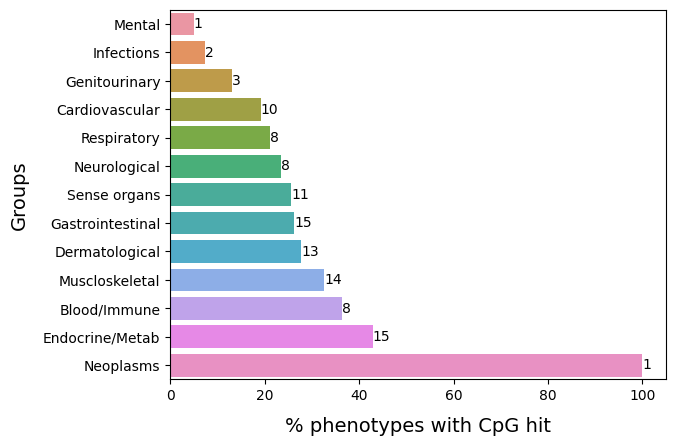

In [107]:
plt2 = sns.barplot(
    data=groups,
    y='group',
    x='pct_signif',
    # palette = palette,
    orient = 'h'
)

plt2.set_xlabel('% phenotypes with CpG hit', fontsize=14, labelpad=10)
plt2.set_ylabel("Groups", fontsize=14, labelpad=10)
plt2.bar_label(plt2.containers[0], labels=groups['n_phenos'], fontsize=10);

In [108]:
# Number of cpg~pheno hits per pheno/group
hits_df = all_signif.groupby(['pheno', 'group', 'color']).size().reset_index(name='n_hits')#.set_index('pheno')
hits_df.sort_values('n_hits')

,pheno,group,color,n_hits
106,Vitamin B group deficiency,Endocrine/Metab,#008000,1
2,Alopecia,Dermatological,#000000,1
6,Ankylosing spondylitis,Muscloskeletal,#7F00FF,1
91,Rheumatoid arthritis,Muscloskeletal,#7F00FF,1
94,Sarcoidosis,Dermatological,#000000,1
...,...,...,...,...
56,Hypothyroidism,Endocrine/Metab,#008000,20
33,Disorders of lipoprotein metabolism and other ...,Endocrine/Metab,#008000,21
8,Atrial fibrillation and flutter,Cardiovascular,#FF00FF,23
40,Diverticular disease [Bowel diverticulosis],Gastrointestinal,#FFD700,24


Text(0, 0.5, 'Groups')

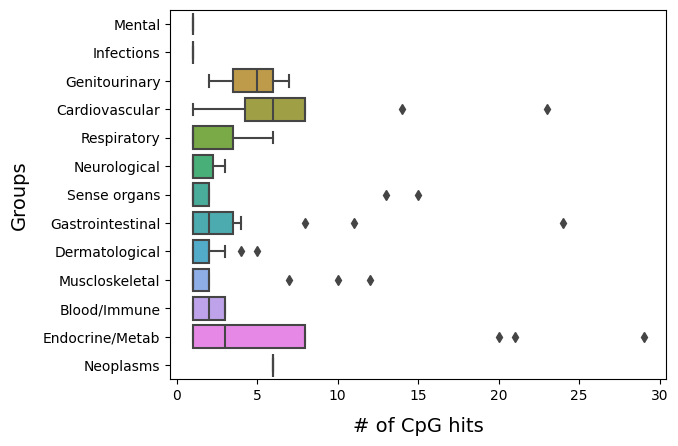

In [112]:

# histogram
plt1 = sns.boxplot(     
    data=hits_df,
    y='group',
    x='n_hits', 
    orient='h',
    # palette=palette, 
    order= groups['group']
)

# plt1.set_xlim(0,400)
plt1.set_xlabel('# of CpG hits', fontsize=14, labelpad=10)
plt1.set_ylabel("Groups", fontsize=14, labelpad=10)